# Notebook 02 — Predição Autorregressiva (H=1 mes)

> **Objetivo:** Treinar e avaliar ARIMA, XGBoost e SVR para prever a inadimplência total com horizonte de **1 mês à frente**, usando apenas o histórico da própria série
>
> Este notebook serve como **baseline autorregressivo**: o ganho dos modelos de sentimento será avaliado no Notebook 07 pela comparação com estes resultados.
>
> **Critério de seleção de lags/ordem:** menor RMSE em validação walk-forward no conjunto de **treinamento**. Correlação é usada apenas como exploração, não como critério de escolha.

In [1]:
%pip install pandas numpy matplotlib statsmodels scikit-learn xgboost-cpu


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Funções Auxiliares

| Métrica | Interpretação |
|---|---|
| **MAE** | Erro médio absoluto em pontos percentuais |
| **RMSE** | Penaliza mais erros grandes; mesma unidade da série |
| **R²** | Quanto da variância foi explicada (1 = perfeito) |
| **Bias** | Erro sistemático: positivo = modelo subestima |


**Estratégia geral do notebook:**

- **Horizonte de previsão:** `HORIZONTE = 1`, ou seja, previsão de inadimplência em `t+1`.
- **Target:** `inad_total_h1`, criado com `shift(-1)`.
- **Data-alvo:** `data_alvo = data + 1 mês`, isto é, o mês efetivamente previsto.
- **Features candidatas dos modelos tabulares:** `inad_total`, `inad_total_L1`, ..., `inad_total_L6`.
- **Split treino/teste:** feito por `data_alvo`, não pela data de referência da serie.
- **Seleção de lags para XGBoost/SVR:** menor RMSE em validação temporal no conjunto de treinamento.
- **Avaliação XGBoost/SVR:** para cada mês de referência (`t`), os modelos usam as informações disponíveis até `t` para prever a inadimplência em `t+1`. Como o alvo da linha de previsão só será conhecido no mês seguinte, essa própria observação não pode ser usada no treinamento da rodada. Por isso, em cada passo da validação walk-forward o modelo é treinado apenas com observações cujo `data_alvo <= t `.
Exemplo: para prever a inadimplência de jan/23, o modelo é posicionado em dez/22. Nessa rodada, ele pode usar as informações disponíveis até dez/22, mas não pode treinar com a observação cujo `data_alvo` é jan/23, pois esse é justamente o valor que se deseja prever. Assim, o treino considera apenas linhas com `data_alvo <= dez/22`.
- **ARIMA:** é ajustado diretamente sobre a série temporal, sem usar manualmente as colunas de lags.


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

#  Métricas
def metricas_regr(y_true, y_pred) -> dict:
    """Calcula métricas de regressão para comparação dos modelos."""
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    bias = float(np.mean(y_true - y_pred))

    lr = LinearRegression().fit(
        np.array(y_true).reshape(-1, 1),
        np.array(y_pred)
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias (obs - prev)": bias,
        "Slope pred~obs": float(lr.coef_[0]),
        "Intercept": float(lr.intercept_),
    }


In [3]:
# 1. Carregar base
CAMINHO_BASE = "base_series.csv"

dados_base = pd.read_csv("base_series.csv")
dados_base["data"] = pd.to_datetime(dados_base["data"])
dados_base = dados_base[dados_base["data"] < "2026-01-01"].copy()
dados_base = dados_base.sort_values("data").reset_index(drop=True)

print(f"Período: {dados_base['data'].min().date()} até {dados_base['data'].max().date()}")
print(f"Observações brutas: {len(dados_base)}")
dados_base


Período: 2019-01-01 até 2025-12-01
Observações brutas: 84


,data,inad_total,inad_total_L1,inad_total_L2,inad_total_L3,inad_total_L4,inad_total_L5,inad_total_L6
0,2019-01-01,2.95,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-02-01,2.91,2.95,NaN,NaN,NaN,NaN,NaN
2,2019-03-01,2.99,2.91,2.95,NaN,NaN,NaN,NaN
3,2019-04-01,3.02,2.99,2.91,2.95,NaN,NaN,NaN
4,2019-05-01,3.05,3.02,2.99,2.91,2.95,NaN,NaN
...,...,...,...,...,...,...,...,...
79,2025-08-01,3.95,3.77,3.57,3.54,3.50,3.28,3.26
80,2025-09-01,3.91,3.95,3.77,3.57,3.54,3.50,3.28
81,2025-10-01,4.00,3.91,3.95,3.77,3.57,3.54,3.50
82,2025-11-01,4.05,4.00,3.91,3.95,3.77,3.57,3.54


In [4]:
# =============================================================
# 3. Criar target e data_alvo para previsão em H=1
# =============================================================
# HORIZONTE = quantidade de meses à frente que será prevista.
# Com HORIZONTE = 1:
# - data_alvo = mês de referência + HORIZONTE
# - inad_total_h1 = inadimplência observada no mês seguinte
# =============================================================

HORIZONTE = 1
TARGET_COL = f"inad_total_h{HORIZONTE}"

df_model = dados_base.copy()

# Criação do alvo: para cada mês t, o target é a inadimplência em t+1.
df_model["data_alvo"] = df_model["data"] + pd.DateOffset(months=HORIZONTE)
df_model[TARGET_COL] = df_model["inad_total"].shift(-HORIZONTE)


df_model

,data,inad_total,inad_total_L1,inad_total_L2,inad_total_L3,inad_total_L4,inad_total_L5,inad_total_L6,data_alvo,inad_total_h1
0,2019-01-01,2.95,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-01,2.91
1,2019-02-01,2.91,2.95,NaN,NaN,NaN,NaN,NaN,2019-03-01,2.99
2,2019-03-01,2.99,2.91,2.95,NaN,NaN,NaN,NaN,2019-04-01,3.02
3,2019-04-01,3.02,2.99,2.91,2.95,NaN,NaN,NaN,2019-05-01,3.05
4,2019-05-01,3.05,3.02,2.99,2.91,2.95,NaN,NaN,2019-06-01,2.95
...,...,...,...,...,...,...,...,...,...,...
79,2025-08-01,3.95,3.77,3.57,3.54,3.50,3.28,3.26,2025-09-01,3.91
80,2025-09-01,3.91,3.95,3.77,3.57,3.54,3.50,3.28,2025-10-01,4.00
81,2025-10-01,4.00,3.91,3.95,3.77,3.57,3.54,3.50,2025-11-01,4.05
82,2025-11-01,4.05,4.00,3.91,3.95,3.77,3.57,3.54,2025-12-01,4.02


In [5]:
# =============================================================
# 4. Base de modelagem
# =============================================================
# Remove linhas com NaN gerados pelos lags iniciais e pelo target final.
# Exemplo:
# - os primeiros meses não têm L6;
# - o último mês não tem t+1 observado.
# =============================================================

FEATURES_INAD = ["inad_total"] + [
    f"inad_total_L{i}"
    for i in range(1, 7)
    if f"inad_total_L{i}" in df_model.columns
]

df_model = df_model.rename(columns={"data": "data_ref"})

cols_conf = df_model.columns.tolist()

df_fit = (
    df_model[cols_conf]
    .dropna(subset=[TARGET_COL] + FEATURES_INAD)
    .copy()
    .reset_index(drop=True)
)

print("=== Base final de modelagem ===")
print(f"Observações após tratamento de nulos: {len(df_fit)}")
print(f"Período de referência: {df_fit['data_ref'].min().date()} → {df_fit['data_ref'].max().date()}")
print(f"Período previsto:      {df_fit['data_alvo'].min().date()} → {df_fit['data_alvo'].max().date()}")

df_fit.to_csv("base_modelagem_inadimplencia.csv")

df_fit

=== Base final de modelagem ===
Observações após tratamento de nulos: 77
Período de referência: 2019-07-01 → 2025-11-01
Período previsto:      2019-08-01 → 2025-12-01


,data_ref,inad_total,inad_total_L1,inad_total_L2,inad_total_L3,inad_total_L4,inad_total_L5,inad_total_L6,data_alvo,inad_total_h1
0,2019-07-01,3.06,2.95,3.05,3.02,2.99,2.91,2.95,2019-08-01,3.04
1,2019-08-01,3.04,3.06,2.95,3.05,3.02,2.99,2.91,2019-09-01,3.06
2,2019-09-01,3.06,3.04,3.06,2.95,3.05,3.02,2.99,2019-10-01,3.03
3,2019-10-01,3.03,3.06,3.04,3.06,2.95,3.05,3.02,2019-11-01,3.00
4,2019-11-01,3.00,3.03,3.06,3.04,3.06,2.95,3.05,2019-12-01,2.94
...,...,...,...,...,...,...,...,...,...,...
72,2025-07-01,3.77,3.57,3.54,3.50,3.28,3.26,3.19,2025-08-01,3.95
73,2025-08-01,3.95,3.77,3.57,3.54,3.50,3.28,3.26,2025-09-01,3.91
74,2025-09-01,3.91,3.95,3.77,3.57,3.54,3.50,3.28,2025-10-01,4.00
75,2025-10-01,4.00,3.91,3.95,3.77,3.57,3.54,3.50,2025-11-01,4.05


In [6]:
# =============================================================
# 5. Split treino/teste — pela data_alvo
# =============================================================
# O corte é feito pelo mês que está sendo previsto.
# Assim, se data_alvo >= SPLIT_DATE, a observação pertence ao teste.
# =============================================================

SPLIT_DATE = "01/01/2024"
split_dt = pd.to_datetime(SPLIT_DATE, dayfirst=True)

treino = df_fit["data_alvo"] < split_dt
teste = df_fit["data_alvo"] >= split_dt

print()
print("=== VALIDAÇÃO DO SPLIT (por data_alvo) ===")
print(f"Treino: alvo de {df_fit.loc[treino, 'data_alvo'].min().date()} "
      f"até {df_fit.loc[treino, 'data_alvo'].max().date()} "
      f"| {treino.sum()} obs  "
      f"(ref: {df_fit.loc[treino, 'data_ref'].min().date()} "
      f"→ {df_fit.loc[treino, 'data_ref'].max().date()})")

print(f"Teste:  alvo de {df_fit.loc[teste, 'data_alvo'].min().date()} "
      f"até {df_fit.loc[teste, 'data_alvo'].max().date()} "
      f"| {teste.sum()} obs  "
      f"(ref: {df_fit.loc[teste, 'data_ref'].min().date()} "
      f"→ {df_fit.loc[teste, 'data_ref'].max().date()})")

# Mantém o nome 'lags' para compatibilidade com as funções seguintes,
# mas aqui a lista inclui também o valor contemporâneo inad_total.
lags = FEATURES_INAD

train_size_global = int(treino.sum())


=== VALIDAÇÃO DO SPLIT (por data_alvo) ===
Treino: alvo de 2019-08-01 até 2023-12-01 | 53 obs  (ref: 2019-07-01 → 2023-11-01)
Teste:  alvo de 2024-01-01 até 2025-12-01 | 24 obs  (ref: 2023-12-01 → 2025-11-01)


## Estrutura da Tabela de Lags e Critério de Seleção

| Coluna | Significado |
|---|---|
| `data_ref` | Mês de referência `t`, isto é, o mês cujas informações observadas são usadas pelo modelo para fazer a previsão |
| `data_alvo` | Mês a ser previsto,  `data_ref + 1 mês` |
| `inad_total_h1` | Inadimplência observada em `t+1`; é a variável-alvo |
| `inad_total` | Inadimplência observada no mês de referência `t` |
| `inad_total_L1` | `shift(1) ou t-1` — inadimplência um mês antes de `t` |
| `inad_total_L2` | `shift(2) ou t-2` — dois meses antes de `t` |
| `inad_total_L3` | `shift(3) ou t-3` — um mês antes de `t` |
| `inad_total_L4` | `shift(4) ou t-4` — quatro meses antes de `t` |
| `inad_total_L5` | `shift(5) ou t-5` — cinco meses antes de `t` |
| `inad_total_L6` | `shift(6) ou t-6` — seis meses antes de `t` |

**Ponto metodológico central:** a previsão é `h=1`. Portanto, para uma linha com referência em `t`, o modelo tenta prever `t+1`.

**Nota sobre o split treino/teste:** o corte é feito por `data_alvo`, pois essa coluna representa o mês previsto pelo modelo. A `data_ref` indica apenas o mês das informações usadas como entrada.

**Critério de seleção de variáveis históricas para XGBoost e SVR:** são testadas diferentes janelas de informação passada. A melhor configuração é aquela com menor **RMSE** em validação temporal (walk-forward) dentro do conjunto de treinamento. 

**Walk-Forward:** esse procedimento, o modelo é reestimado progressivamente ao longo do tempo, sempre usando apenas observações passadas para prever o próximo mês, evitando vazamento de informação futura.

## ARIMA — Horizonte H=1

O ARIMA é estimado diretamente sobre a série temporal de inadimplência. Diferentemente de XGBoost e SVR, ele não usa manualmente as colunas `inad_total_L1`, `inad_total_L2`, ..., `inad_total_L6` como variáveis explicativas. A dependência temporal é incorporada pelos próprios parâmetros do modelo.

Antes da estimação do ARIMA, é importante verificar se a série é estacionária. Uma série estacionária é aquela cujas propriedades estatísticas, como média e variância, permanecem estáveis ao longo do tempo. Em termos intuitivos, ela oscila em torno de um padrão constante. Já uma série não estacionária apresenta mudanças persistentes de nível, tendência ou variabilidade, o que pode dificultar a estimação e a interpretação de modelos de séries temporais.

Essa verificação é relevante porque os componentes AR (autorregressivos) e MA (medias moveis) do modelo são mais adequados para séries estacionárias. Quando a série apresenta não estacionariedade, o componente `d` do ARIMA indica o número de diferenciações necessárias para transformar a série original em uma série mais estável. A diferenciação consiste em substituir a série original pela variação entre períodos consecutivos, por exemplo, comparar `I_t` com `I_{t-1}` em vez de usar diretamente o nível de `I_t`.

Neste notebook, essa avaliação é feita por meio do teste ADF (Augmented Dickey-Fuller), utilizado para verificar a presença de raiz unitária. A hipótese nula do teste é que a série possui raiz unitária, isto é, apresenta comportamento não estacionário. Assim, quando o p-valor do teste é suficientemente baixo, rejeita-se a hipótese nula e há evidência de estacionariedade. Quando isso não ocorre, considera-se a necessidade de componentes integrados (I) na especificação ARIMA.

Os parâmetros do ARIMA são:

- AR `p`: componente autorregressivo, isto é, dependência da série em relação aos seus valores passados.
- I `d`: número de diferenciações, usado quando a série não é estacionária.
- MA `q`: componente de médias móveis, isto é, relação da série com erros passados do modelo.

Nesta versão, o horizonte é de um mês:

$$I_{t+1} \leftarrow I_t, I_{t-1}, \ldots$$

Ou seja, o modelo utiliza o histórico observado da inadimplência até o mês de referência `t` para prever a inadimplência no mês seguinte, `t+1`.

**Seleção da ordem ARIMA:** a ordem `(p,d,q)` é escolhida pelo menor AIC no conjunto de treinamento. O AIC (Critério de Informação de Akaike) compara modelos considerando simultaneamente a qualidade do ajuste e uma penalização por complexidade. Assim, evita-se escolher modelos excessivamente complexos apenas porque se ajustam melhor aos dados de treino. A avaliação final, porém, é feita fora da amostra por validação walk-forward no conjunto de teste.

**Correção de bias:** o viés médio é estimado exclusivamente no treinamento e depois aplicado ao teste. Assim, a correção não usa informação futura do período de teste.

In [7]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

A análise da ACF e da PACF é utilizada como etapa diagnóstica na identificação preliminar da estrutura ARIMA, pois permite observar a autocorrelação da série em diferentes defasagens e apoiar a definição dos componentes `p` e `q`. No notebook, essa análise visual é combinada com a seleção por AIC, adotando-se como especificação final o modelo com menor critério de informação no conjunto de treinamento.

- A ACF — função de autocorrelação — mostra a correlação da série com seus próprios valores passados, permitindo observar a persistência temporal da variável. 
- A PACF — função de autocorrelação parcial — mostra a relação entre a série atual e uma defasagem específica, descontando o efeito das defasagens intermediárias.

In [8]:
# =============================================================
# ARIMA — modelo sem variáveis externas
# =============================================================

def teste_adf_serie(y: pd.Series):
    """
    Aplica o teste ADF — Dickey-Fuller aumentado, usado para avaliar
    se a série é estacionária, isto é, se não apresenta tendência estocástica forte.
    """
    y = y.dropna().astype(float)

    resultado = adfuller(y)

    print("=== Teste ADF — estacionariedade ===")
    print(f"Estatística ADF: {resultado[0]:.4f}")
    print(f"p-valor:         {resultado[1]:.4f}")

    if resultado[1] <= 0.05:
        print("Interpretação: há indício de estacionariedade. Sugestão inicial: d = 0.")
        d_sugerido = 0
    else:
        print("Interpretação: há indício de não estacionariedade. Sugestão inicial: d = 1.")
        d_sugerido = 1

    return d_sugerido


def plotar_acf_pacf(y: pd.Series, d: int = 0):
    """
    Plota ACF e PACF.

    ACF — função de autocorrelação: mostra a correlação da série com seus valores passados.
    PACF — autocorrelação parcial: ajuda a observar quais defasagens têm efeito mais direto.
    """
    y = y.dropna().astype(float)

    if d > 0:
        serie_analise = y.diff(d).dropna()
        titulo = f"Série após {d} diferença(s)"
    else:
        serie_analise = y
        titulo = "Série original"

    max_lags = min(24, max(1, len(serie_analise) // 2 - 1))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(serie_analise)
    axes[0].set_title(titulo)

    plot_acf(serie_analise, lags=max_lags, ax=axes[1])
    axes[1].set_title("ACF")

    plot_pacf(serie_analise, lags=max_lags, ax=axes[2], method="ywm")
    axes[2].set_title("PACF")

    plt.tight_layout()
    plt.show()


def ajustar_arima(endog: pd.Series, order=(1, 0, 0)):
    """
    Ajusta um modelo ARIMA(p,d,q) diretamente pela classe ARIMA do statsmodels.

    p = número de termos autorregressivos, isto é, valores passados da própria série.
    d = número de diferenciações para tornar a série estacionária.
    q = número de termos de médias móveis, isto é, erros passados usados no modelo.
    """
    endog = endog.dropna().astype(float)

    modelo = ARIMA(
        endog,
        order=order,
        enforce_stationarity=True,
        enforce_invertibility=True
    )

    return modelo.fit(method_kwargs={"maxiter": 700})


def selecionar_ordem_arima_aic(
    y_treino: pd.Series,
    p_values=range(0, 7),
    d_values=(0, 1),
    q_values=range(0, 7)
):
    """
    Testa combinações ARIMA(p,d,q) e seleciona o modelo com menor AIC.

    AIC — Critério de Informação de Akaike, métrica que compara modelos
    considerando ajuste e complexidade. Quanto menor o AIC, melhor o equilíbrio
    entre aderência aos dados e parcimônia.
    """
    y_treino = y_treino.dropna().astype(float)

    resultados = []

    for p, d, q in itertools.product(p_values, d_values, q_values):

        # Evita modelo sem parte AR e sem parte MA.
        # ARIMA(0,d,0) pode ser testado, mas aqui deixamos fora para focar em modelos com dinâmica temporal.
        if p == 0 and q == 0:
            continue

        try:
            ajuste = ajustar_arima(y_treino, order=(p, d, q))

            resultados.append({
                "modelo": f"ARIMA({p},{d},{q})",
                "p": p,
                "d": d,
                "q": q,
                "ordem_arima": (p, d, q),
                "AIC": ajuste.aic,
                "BIC": ajuste.bic,
                "convergiu": True
            })

        except Exception as e:
            resultados.append({
                "modelo": f"ARIMA({p},{d},{q})",
                "p": p,
                "d": d,
                "q": q,
                "ordem_arima": (p, d, q),
                "AIC": np.nan,
                "BIC": np.nan,
                "convergiu": False
            })

    df_resultados = (
        pd.DataFrame(resultados)
        .dropna(subset=["AIC"])
        .sort_values("AIC")
        .reset_index(drop=True)
    )

    if df_resultados.empty:
        raise ValueError("Nenhum modelo ARIMA válido foi estimado.")

    melhor_ordem = tuple(df_resultados.loc[0, "ordem_arima"])

    return melhor_ordem, df_resultados


def diagnostico_residuos_arima(ajuste):
    """
    Gera gráficos de diagnóstico dos resíduos.

    Resíduos são os erros do modelo. Em um bom ajuste, eles devem se comportar
    de forma aproximadamente aleatória, sem autocorrelação relevante.
    """
    residuos = pd.Series(ajuste.resid).dropna()

    max_lags = min(24, max(1, len(residuos) // 2 - 1))

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(residuos)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Resíduos do ARIMA")

    plot_acf(residuos, lags=max_lags, ax=axes[0, 1])
    axes[0, 1].set_title("ACF dos resíduos")

    axes[1, 0].hist(residuos, bins=12, density=True)
    axes[1, 0].set_title("Histograma dos resíduos")

    sm.qqplot(residuos, line="45", ax=axes[1, 1])
    axes[1, 1].set_title("QQ-plot dos resíduos")

    plt.tight_layout()
    plt.show()


def walk_forward_arima_h(endog: pd.Series, train_size: int, order=(1, 0, 0), h: int = 1):
    """
    Executa walk-forward para ARIMA com horizonte h.

    Para cada posição i:
    - o modelo treina com endog.iloc[:i];
    - prevê h passos à frente;
    - guarda apenas a previsão do h-ésimo passo.
    """
    endog = endog.dropna().astype(float)

    previsoes = []
    limites_inf = []
    limites_sup = []
    idxs = []

    for i in range(train_size, len(endog) - h + 1):

        historico = endog.iloc[:i]

        try:
            ajuste = ajustar_arima(historico, order=order)

            forecast = ajuste.get_forecast(steps=h)

            yhat = float(forecast.predicted_mean.iloc[-1])

            conf_int = forecast.conf_int(alpha=0.05).iloc[-1]
            low = float(conf_int.iloc[0])
            upper = float(conf_int.iloc[1])

        except Exception:
            yhat = np.nan
            low = np.nan
            upper = np.nan

        previsoes.append(yhat)
        limites_inf.append(low)
        limites_sup.append(upper)
        idxs.append(endog.index[i + h - 1])

    return pd.DataFrame({
        "forecast": previsoes,
        "lower_95": limites_inf,
        "upper_95": limites_sup
    }, index=idxs).dropna()

=== Série utilizada no ARIMA ===
Série alinhada pela data_alvo, para manter comparação com XGBoost e SVR.
Target utilizado: inad_total_h1
Início da série: 2019-08-01
Fim da série:    2025-12-01
Total de observações: 77
=== Teste ADF — estacionariedade ===
Estatística ADF: -0.8720
p-valor:         0.7970
Interpretação: há indício de não estacionariedade. Sugestão inicial: d = 1.


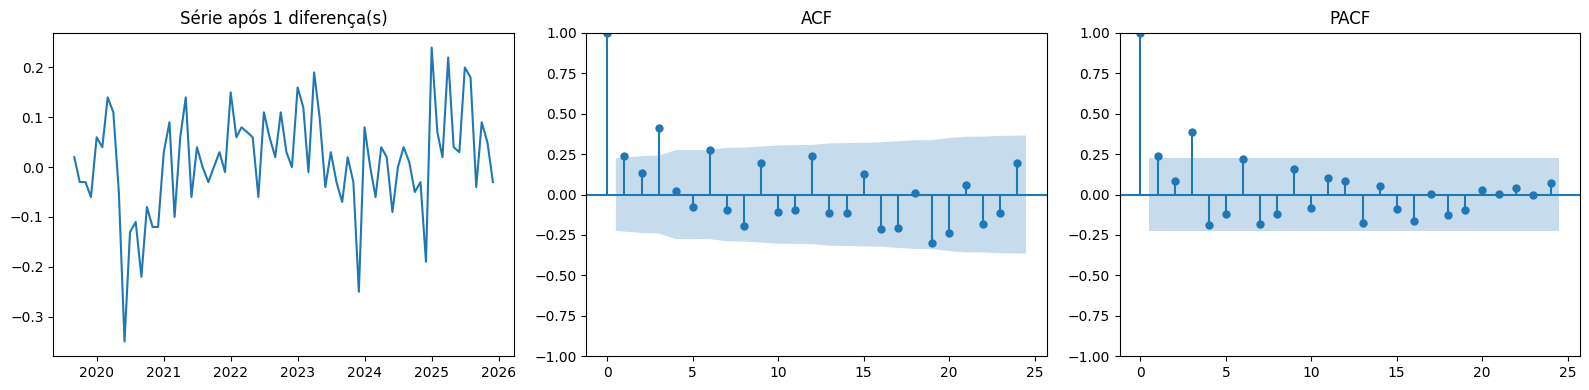


=== Split ARIMA — horizonte H=1 ===
Treino inicial: 2019-08-01 → 2023-12-01 (53 obs)
Primeiro alvo de teste: 2024-01-01 | Split: 2024-01-01
Último alvo de teste:   2025-12-01

Selecionando ordem ARIMA pelo menor AIC no conjunto de treino...


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information 


Tabela de seleção ARIMA por AIC:


,modelo,p,d,q,AIC,BIC,convergiu
0,"ARIMA(2,1,4)",2,1,4,-105.7023,-92.0436,True
1,"ARIMA(3,1,3)",3,1,3,-105.2881,-91.6294,True
2,"ARIMA(2,1,5)",2,1,5,-104.4593,-88.8493,True
3,"ARIMA(3,1,4)",3,1,4,-104.1306,-88.5206,True
4,"ARIMA(4,1,3)",4,1,3,-104.1122,-88.5022,True
5,"ARIMA(5,1,3)",5,1,3,-103.5678,-86.0066,True
6,"ARIMA(3,1,6)",3,1,6,-103.3188,-83.8064,True
7,"ARIMA(4,1,4)",4,1,4,-103.2279,-85.6667,True
8,"ARIMA(6,1,2)",6,1,2,-103.1919,-85.6307,True
9,"ARIMA(5,1,4)",5,1,4,-102.6872,-83.1748,True



Ordem selecionada pelo menor AIC: ARIMA(2, 1, 4)

Resumo do modelo ARIMA(2, 1, 4) ajustado no treino:


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          inad_total_h1   No. Observations:                   53
Model:                 ARIMA(2, 1, 4)   Log Likelihood                  59.851
Date:                Fri, 08 May 2026   AIC                           -105.702
Time:                        05:42:38   BIC                            -92.044
Sample:                    08-01-2019   HQIC                          -100.466
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9547      0.127     -7.542      0.000      -1.203      -0.707
ar.L2         -0.9108      0.098     -9.324      0.000      -1.102      -0.719
ma.L1          1.5844      0.195      8.143      0.0

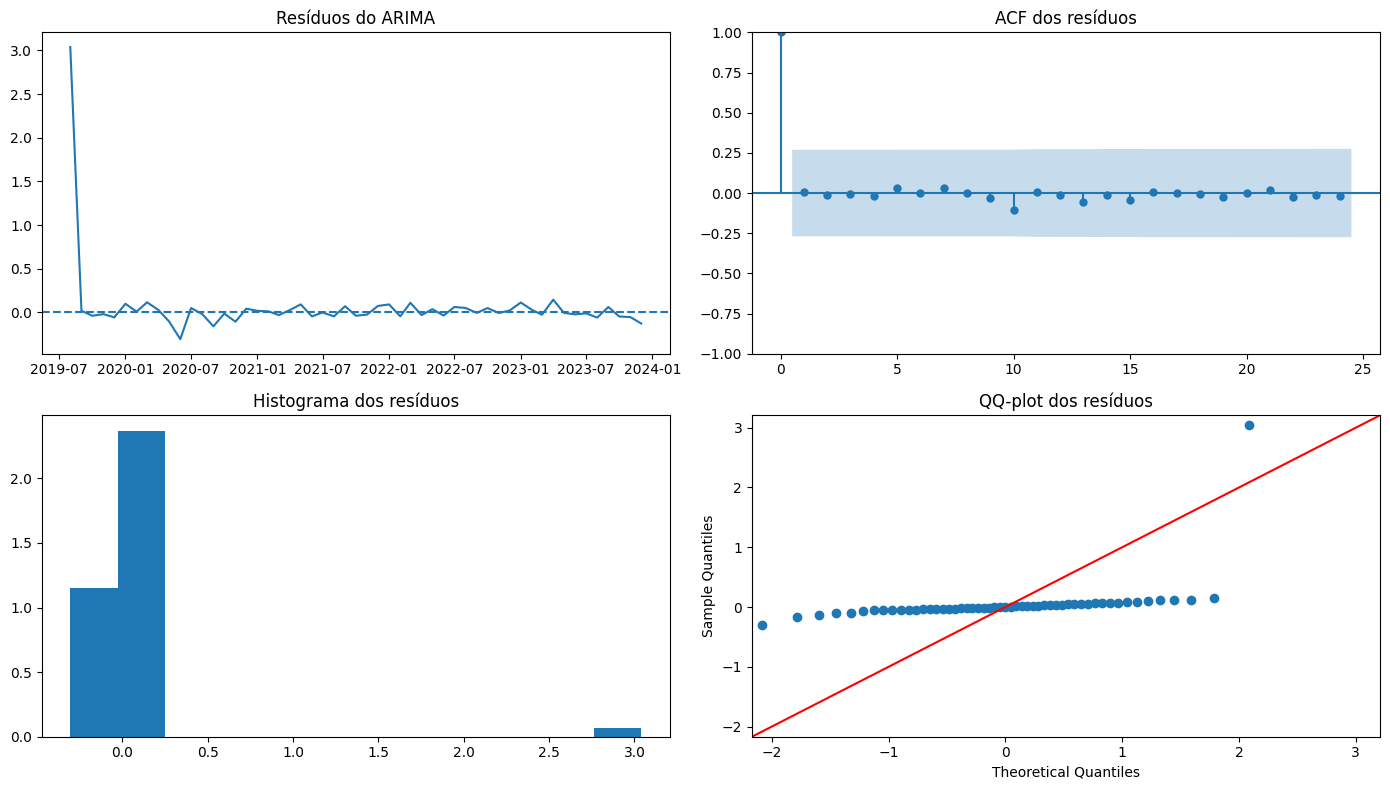

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py


=== Bias correction ===
Bias estimado no treino: 0.007279
Interpretação: esse valor será somado às previsões do teste.


/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information 


Métricas no teste — ARIMA(2, 1, 4):


,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
"ARIMA(2, 1, 4) (h=1)",0.072136,0.099060,0.909589,0.027005,0.940752,0.176141
"ARIMA(2, 1, 4) (h=1) + bias",0.070517,0.097328,0.912723,0.019726,0.940752,0.183420


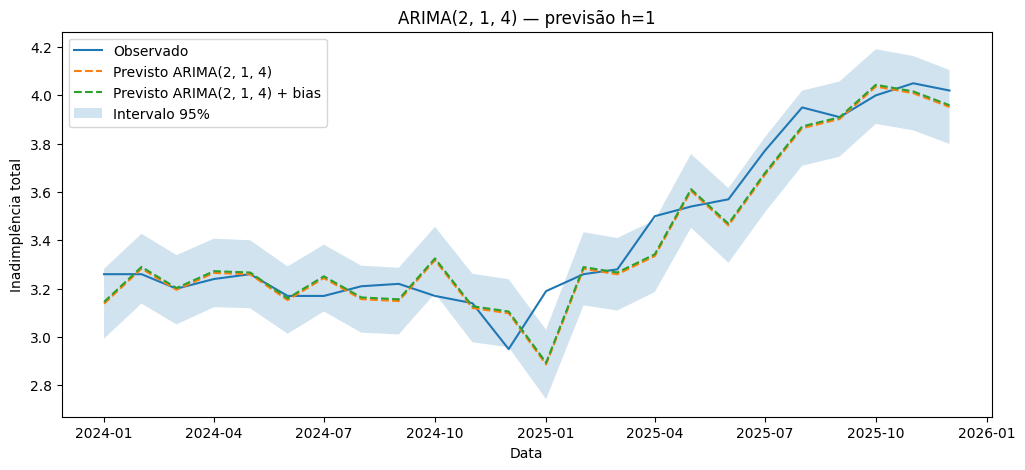

In [9]:
# =============================================================
# ARIMA — horizonte H=1
# Série usada: target alinhado pela data_alvo
# Seleção da ordem ARIMA(p,d,q) por AIC no treino
# Avaliação final por walk-forward no teste
# =============================================================

H = HORIZONTE

# =============================================================
# 0. Série ARIMA alinhada à mesma base de comparação dos modelos tabulares
# =============================================================
# Para manter comparabilidade, o ARIMA é avaliado nos mesmos meses-alvo
# usados nos modelos XGBoost e SVR.
# =============================================================

y_arima = (
    df_fit[["data_alvo", TARGET_COL]]
    .copy()
    .assign(data_alvo=lambda x: pd.to_datetime(x["data_alvo"]))
    .dropna(subset=["data_alvo", TARGET_COL])
    .drop_duplicates(subset="data_alvo", keep="last")
    .set_index("data_alvo")[TARGET_COL]
    .sort_index()
    .astype(float)
)

y_arima.index.name = "data"

print("=== Série utilizada no ARIMA ===")
print("Série alinhada pela data_alvo, para manter comparação com XGBoost e SVR.")
print(f"Target utilizado: {TARGET_COL}")
print(f"Início da série: {y_arima.index.min().date()}")
print(f"Fim da série:    {y_arima.index.max().date()}")
print(f"Total de observações: {len(y_arima)}")

# =============================================================
# 1. Análise inicial: estacionariedade, ACF e PACF
# =============================================================
# ADF = teste de estacionariedade.
# ACF/PACF = gráficos de autocorrelação.
# =============================================================

d_sugerido = teste_adf_serie(y_arima)

plotar_acf_pacf(y_arima, d=d_sugerido)

# =============================================================
# 2. Split temporal para horizonte H=1
# =============================================================

split_dt = pd.to_datetime(SPLIT_DATE, dayfirst=True)

posicoes_teste = np.where(y_arima.index >= split_dt)[0]

if len(posicoes_teste) == 0:
    raise ValueError("SPLIT_DATE está depois do fim da série.")

primeira_pos_alvo_teste = int(posicoes_teste[0])

# Para H=1, a primeira previsão de teste tem alvo exatamente no SPLIT_DATE.
train_size_h1 = primeira_pos_alvo_teste - H + 1

if train_size_h1 <= 0:
    raise ValueError("Treino insuficiente para ARIMA com horizonte H=1.")

primeiro_alvo_arima = y_arima.index[train_size_h1 + H - 1]

print()
print("=== Split ARIMA — horizonte H=1 ===")
print(f"Treino inicial: {y_arima.index[0].date()} → {y_arima.index[train_size_h1-1].date()} ({train_size_h1} obs)")
print(f"Primeiro alvo de teste: {primeiro_alvo_arima.date()} | Split: {split_dt.date()}")
print(f"Último alvo de teste:   {y_arima.index[-1].date()}")

y_treino_arima = y_arima.iloc[:train_size_h1]

# =============================================================
# 3. Seleção da ordem ARIMA(p,d,q) por AIC no treino
# =============================================================

print()
print("Selecionando ordem ARIMA pelo menor AIC no conjunto de treino...")

ordem_h1, df_sel_arima = selecionar_ordem_arima_aic(
    y_treino=y_treino_arima,
    p_values=range(0, 7),
    d_values=(d_sugerido,),
    q_values=range(0, 7)
)

ordem_h1 = tuple(int(x) for x in ordem_h1)

print()
print("Tabela de seleção ARIMA por AIC:")
display(
    df_sel_arima[
        ["modelo", "p", "d", "q", "AIC", "BIC", "convergiu"]
    ].head(10).round(4)
)

print(f"\nOrdem selecionada pelo menor AIC: ARIMA{ordem_h1}")

# =============================================================
# 4. Ajuste do modelo selecionado no treino e diagnóstico dos resíduos
# =============================================================

print()
print(f"Resumo do modelo ARIMA{ordem_h1} ajustado no treino:")

ajuste_final_treino = ajustar_arima(y_treino_arima, order=ordem_h1)

print(ajuste_final_treino.summary())

diagnostico_residuos_arima(ajuste_final_treino)

# =============================================================
# 5. Bias correction estimada no treino
# =============================================================
# Bias correction = correção de viés, isto é, ajuste médio aplicado às previsões
# quando o modelo tende a errar sistematicamente para cima ou para baixo.
# =============================================================

min_obs_bias = min(15, max(5, len(y_treino_arima) // 2))

forecast_treino_bias = walk_forward_arima_h(
    endog=y_treino_arima,
    train_size=min_obs_bias,
    order=ordem_h1,
    h=H
)

y_true_bias = y_treino_arima.loc[forecast_treino_bias.index]
y_pred_bias = forecast_treino_bias["forecast"]

bias_h1 = float((y_true_bias - y_pred_bias).mean())

print()
print("=== Bias correction ===")
print(f"Bias estimado no treino: {bias_h1:.6f}")
print("Interpretação: esse valor será somado às previsões do teste.")

# =============================================================
# 6. Walk-forward no conjunto de teste
# =============================================================

forecast_h1 = walk_forward_arima_h(
    endog=y_arima,
    train_size=train_size_h1,
    order=ordem_h1,
    h=H
)

# Mantém apenas previsões cujo alvo está no período de teste.
forecast_h1 = forecast_h1[forecast_h1.index >= split_dt]

# Garante que o ARIMA será avaliado nos mesmos meses de teste do df_fit.
idx_teste_comum = pd.DatetimeIndex(
    pd.to_datetime(df_fit.loc[teste, "data_alvo"].sort_values().unique())
)

forecast_h1 = forecast_h1.loc[forecast_h1.index.isin(idx_teste_comum)]

yhat_h1 = forecast_h1["forecast"]
y_true_h1 = y_arima.loc[yhat_h1.index]

res_h1 = metricas_regr(y_true_h1, yhat_h1)

# Correção de bias estimada no treino.
yhat_h1_bc = yhat_h1 + bias_h1

res_h1_bc = metricas_regr(y_true_h1, yhat_h1_bc)

print()
print(f"Métricas no teste — ARIMA{ordem_h1}:")

tabela_h1 = pd.DataFrame([
    {"Modelo": f"ARIMA{ordem_h1} (h=1)",        **res_h1},
    {"Modelo": f"ARIMA{ordem_h1} (h=1) + bias", **res_h1_bc},
]).set_index("Modelo").round(6)

display(tabela_h1)

# =============================================================
# 7. Gráfico observado vs. previsto
# =============================================================

plt.figure(figsize=(12, 5))

plt.plot(y_true_h1.index, y_true_h1, label="Observado")
plt.plot(yhat_h1.index, yhat_h1, linestyle="--", label=f"Previsto ARIMA{ordem_h1}")
plt.plot(yhat_h1_bc.index, yhat_h1_bc, linestyle="--", label=f"Previsto ARIMA{ordem_h1} + bias")

plt.fill_between(
    forecast_h1.index,
    forecast_h1["lower_95"],
    forecast_h1["upper_95"],
    alpha=0.2,
    label="Intervalo 95%"
)

plt.title(f"ARIMA{ordem_h1} — previsão h={H}")
plt.xlabel("Data")
plt.ylabel("Inadimplência total")
plt.legend()
plt.show()

A ordem ARIMA é selecionada somente com dados do conjunto de treinamento, usando o menor AIC entre as combinações testadas. Essa escolha evita definir a especificação de forma arbitrária e mantém a avaliação final separada da seleção do modelo. O parâmetro `d` é definido a partir do teste ADF: quando há indício de não estacionariedade. Após a escolha da ordem, o desempenho é medido fora da amostra por validação walk-forward com horizonte de um mês.

Embora modelos SARIMA possam ser considerados para séries mensais com componente sazonal, optou-se pelo ARIMA neste trabalho por três razões principais. Primeiro, a análise visual da série diferenciada e dos correlogramas não indicou um padrão sazonal suficientemente forte para justificar a inclusão de componentes sazonais. Segundo, a amostra disponível é relativamente curta, o que torna a estimação de modelos mais parametrizados menos estável. Terceiro, buscou-se manter uma especificação parcimoniosa e comparável aos demais modelos preditivos avaliados.

# Modelos Regressivos

Diferentemente do ARIMA, que incorpora a dependência temporal internamente, XGBoost e SVR são modelos supervisionados de regressão. Por isso, a série temporal precisa ser transformada em uma base tabular: os valores históricos da inadimplência (`inad_total`, `inad_total_L1`, ..., `inad_total_L6`) entram como variáveis explicativas, e a inadimplência no mês seguinte (`inad_total_h1`) entra como variável-alvo. Para preservar a lógica temporal, a validação é feita por walk-forward, impedindo que o modelo use informações cujo alvo ainda não estaria disponível no momento da previsão.

In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [11]:
# =============================================================
# Modelos regressores — XGBoost e SVR
# =============================================================

TARGET_COL = f"inad_total_h{HORIZONTE}"

# 'lags' inclui o valor contemporâneo em t e as defasagens até t-6.
lags = FEATURES_INAD

split_dt = pd.to_datetime(SPLIT_DATE, dayfirst=True)

df_reg = df_fit.copy()

# Garante que as colunas de data estejam no formato correto.
df_reg["data_ref"] = pd.to_datetime(df_reg["data_ref"])
df_reg["data_alvo"] = pd.to_datetime(df_reg["data_alvo"])

df_reg = (
    df_reg[["data_ref", "data_alvo"] + lags + [TARGET_COL]]
    .dropna()
    .sort_values(["data_alvo", "data_ref"])
    .reset_index(drop=True)
)

print("=== Base dos modelos regressores ===")
print(f"Target: {TARGET_COL}")
print(f"Features candidatas: {lags}")
print(f"Total de observações: {len(df_reg)}")

print(f"Treino: {df_reg.loc[df_reg['data_alvo'] < split_dt, 'data_alvo'].min().date()} "
      f"→ {df_reg.loc[df_reg['data_alvo'] < split_dt, 'data_alvo'].max().date()} "
      f"| {(df_reg['data_alvo'] < split_dt).sum()} obs")

print(f"Teste:  {df_reg.loc[df_reg['data_alvo'] >= split_dt, 'data_alvo'].min().date()} "
      f"→ {df_reg.loc[df_reg['data_alvo'] >= split_dt, 'data_alvo'].max().date()} "
      f"| {(df_reg['data_alvo'] >= split_dt).sum()} obs")

df_reg.head()

=== Base dos modelos regressores ===
Target: inad_total_h1
Features candidatas: ['inad_total', 'inad_total_L1', 'inad_total_L2', 'inad_total_L3', 'inad_total_L4', 'inad_total_L5', 'inad_total_L6']
Total de observações: 77
Treino: 2019-08-01 → 2023-12-01 | 53 obs
Teste:  2024-01-01 → 2025-12-01 | 24 obs


,data_ref,data_alvo,inad_total,inad_total_L1,inad_total_L2,inad_total_L3,inad_total_L4,inad_total_L5,inad_total_L6,inad_total_h1
0,2019-07-01,2019-08-01,3.06,2.95,3.05,3.02,2.99,2.91,2.95,3.04
1,2019-08-01,2019-09-01,3.04,3.06,2.95,3.05,3.02,2.99,2.91,3.06
2,2019-09-01,2019-10-01,3.06,3.04,3.06,2.95,3.05,3.02,2.99,3.03
3,2019-10-01,2019-11-01,3.03,3.06,3.04,3.06,2.95,3.05,3.02,3.00
4,2019-11-01,2019-12-01,3.00,3.03,3.06,3.04,3.06,2.95,3.05,2.94


In [12]:
# =============================================================
# Funções auxiliares — modelos regressores com validação walk-forward
# =============================================================

def walk_forward_tabular(
    df: pd.DataFrame,
    feature_cols,
    target_col: str,
    model_factory_fn,
    start_target_date=None,
    min_train_obs: int = 15,
    data_ref_col: str = "data_ref",
    data_alvo_col: str = "data_alvo",
):
    """
    Executa validação walk-forward para modelos regressores tabulares,
    como XGBoost e SVR.

    Para cada linha de previsão:
    - data_ref representa o mês cujas informações são usadas como entrada;
    - data_alvo representa o mês que se deseja prever.

    Em cada rodada, o modelo é treinado apenas com observações cujo
    data_alvo seja menor ou igual à data_ref da linha prevista.

    Assim, para prever t+1, o modelo usa somente observações cujo alvo
    já estaria conhecido até t, evitando vazamento temporal.
    """

    preds, idxs = [], []

    df = df.copy()

    # Valida colunas obrigatórias.
    colunas_necessarias = [data_ref_col, data_alvo_col, target_col] + list(feature_cols)
    colunas_faltantes = [col for col in colunas_necessarias if col not in df.columns]

    if colunas_faltantes:
        raise ValueError(f"Colunas ausentes na base: {colunas_faltantes}")

    # Garante formato de data.
    df[data_ref_col] = pd.to_datetime(df[data_ref_col])
    df[data_alvo_col] = pd.to_datetime(df[data_alvo_col])

    if start_target_date is not None:
        start_target_date = pd.to_datetime(start_target_date)

    df = df.sort_values([data_alvo_col, data_ref_col]).reset_index(drop=True)

    for i, row in df.iterrows():

        # Se start_target_date foi informado, só gera previsões para esse período em diante.
        if start_target_date is not None and row[data_alvo_col] < start_target_date:
            continue

        data_ref = row[data_ref_col]

        # Para prever uma linha com referência t, usa apenas observações
        # cujo alvo já seria conhecido até t.
        treino_disponivel = df[df[data_alvo_col] <= data_ref].copy()

        if len(treino_disponivel) < min_train_obs:
            continue

        X_train = treino_disponivel[feature_cols]
        y_train = treino_disponivel[target_col]
        X_pred = df.loc[[i], feature_cols]

        # Evita treinar/prever com valores ausentes.
        if (
            X_train.isna().sum().sum() > 0
            or y_train.isna().sum() > 0
            or X_pred.isna().sum().sum() > 0
        ):
            continue

        modelo = model_factory_fn()
        modelo.fit(X_train, y_train)

        pred = float(modelo.predict(X_pred)[0])

        preds.append(pred)
        idxs.append(i)

    return pd.Series(preds, index=idxs)


def selecionar_lags_rmse_wf(
    df_treino: pd.DataFrame,
    lag_cols_ordered,
    target_col: str,
    model_factory_fn,
    modelo_nome: str,
    min_obs_wf: int = 15,
):
    """
    Testa diferentes quantidades de valores históricos e seleciona a configuração
    com menor RMSE em validação walk-forward dentro do conjunto de treinamento.

    Exemplo:
    k = 1 usa apenas inad_total, isto é, o valor em t
    k = 2 usa inad_total e inad_total_L1
    ...
    k = 7 usa inad_total até inad_total_L6
    """

    resultados = []

    for k in range(1, len(lag_cols_ordered) + 1):

        cols_k = lag_cols_ordered[:k]

        preds = walk_forward_tabular(
            df=df_treino,
            feature_cols=cols_k,
            target_col=target_col,
            model_factory_fn=model_factory_fn,
            start_target_date=None,
            min_train_obs=min_obs_wf,
            data_ref_col="data_ref",
            data_alvo_col="data_alvo",
        )

        if len(preds) < 3:
            continue

        y_true = df_treino.loc[preds.index, target_col]

        resultados.append({
            "modelo": modelo_nome,
            "qtd_valores_historicos": int(k),
            "features_usadas": " | ".join(cols_k),
            "mae_treino": round(float(mean_absolute_error(y_true, preds)), 6),
            "rmse_treino": round(float(root_mean_squared_error(y_true, preds)), 6),
            "r2_treino": round(float(r2_score(y_true, preds)), 6),
            "n_predicoes_treino": int(len(y_true)),
        })

    if not resultados:
        raise ValueError(f"Nenhuma configuração válida para {modelo_nome}.")

    df_resultados = (
        pd.DataFrame(resultados)
        .sort_values("rmse_treino")
        .reset_index(drop=True)
    )

    melhor_k = int(df_resultados.iloc[0]["qtd_valores_historicos"])

    return melhor_k, df_resultados

In [13]:
def rodar_regressor_temporal(
    nome_modelo,
    model_factory_fn,
    df_base,
    lags,
    target_col,
    split_dt,
    min_obs_wf=15
):
    """
    Roda um modelo regressor com validação temporal.

    A lógica é:
    1. seleciona a melhor quantidade de lags no treino;
    2. estima o bias no treino;
    3. avalia o modelo no teste;
    4. retorna as métricas.
    """

    treino = df_base["data_alvo"] < split_dt
    df_treino = df_base.loc[treino].reset_index(drop=True)

    print()
    print(f"================ {nome_modelo} ================")

    print(f"Treino {nome_modelo}: {df_treino['data_alvo'].min().date()} "
          f"→ {df_treino['data_alvo'].max().date()} "
          f"({len(df_treino)} obs)")

    print(f"Teste  {nome_modelo}: {df_base.loc[~treino, 'data_alvo'].min().date()} "
          f"→ {df_base.loc[~treino, 'data_alvo'].max().date()} "
          f"({(~treino).sum()} obs)")

    # Seleção da quantidade de lags no treino
    melhor_k, tabela_selecao = selecionar_lags_rmse_wf(
        df_treino=df_treino,
        lag_cols_ordered=lags,
        target_col=target_col,
        model_factory_fn=model_factory_fn,
        modelo_nome=nome_modelo,
        min_obs_wf=min_obs_wf,
    )

    features = lags[:melhor_k]

    print()
    print(f"Melhor k para {nome_modelo}: {melhor_k}")
    print(f"Features usadas: {features}")

    display(
        tabela_selecao[
            ["modelo", "qtd_valores_historicos", "features_usadas",
             "rmse_treino", "mae_treino", "r2_treino", "n_predicoes_treino"]
        ]
    )

    # Bias estimado no treino
    yhat_treino = walk_forward_tabular(
        df=df_treino,
        feature_cols=features,
        target_col=target_col,
        model_factory_fn=model_factory_fn,
        start_target_date=None,
        min_train_obs=min_obs_wf,
    )

    y_true_treino = df_treino.loc[yhat_treino.index, target_col]
    bias_treino = float((y_true_treino - yhat_treino).mean())

    print()
    print(f"Bias estimado no treino — {nome_modelo}: {bias_treino:.6f}")

    # Previsão no teste
    yhat_teste = walk_forward_tabular(
        df=df_base,
        feature_cols=features,
        target_col=target_col,
        model_factory_fn=model_factory_fn,
        start_target_date=split_dt,
        min_train_obs=min_obs_wf,
    )

    y_true_teste = df_base.loc[yhat_teste.index, target_col]

    # Métricas sem bias
    res = metricas_regr(y_true_teste, yhat_teste)

    # Métricas com bias correction
    yhat_teste_bc = yhat_teste + bias_treino
    res_bc = metricas_regr(y_true_teste, yhat_teste_bc)

    tabela_metricas = pd.DataFrame([
        {"Modelo": f"{nome_modelo} (h={HORIZONTE}, k={melhor_k})", **res},
        {"Modelo": f"{nome_modelo} (h={HORIZONTE}, k={melhor_k}) + bias", **res_bc},
    ]).set_index("Modelo").round(6)

    print()
    print(f"Métricas no teste — {nome_modelo}:")
    display(tabela_metricas)

    return tabela_metricas, tabela_selecao, yhat_teste, yhat_teste_bc

## XGBoost — Horizonte H=1 (Direct Forecasting)

Features candidatas: `inad_total` | `inad_total_L1` | … | `inad_total_L6`.

O modelo aprende diretamente `inad_total_h1` a partir das informações disponíveis no mês de referência `t`. 

**Seleção de k:** menor RMSE em walk-forward no conjunto de treinamento.

**Interpretação de k:**

- `k=1`: usa apenas `inad_total`, isto é, o valor observado em `t`;
- `k=2`: usa `inad_total` e `inad_total_L1`;
- ...
- `k=7`: usa `inad_total` até `inad_total_L6`.

In [14]:
def criar_xgboost():
    return XGBRegressor(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective="reg:squarederror",
    )

tabela_xgb_h1, selecao_xgb, yhat_xgb_h1, yhat_xgb_h1_bc = rodar_regressor_temporal(
    nome_modelo="XGBoost",
    model_factory_fn=criar_xgboost,
    df_base=df_reg,
    lags=lags,
    target_col=TARGET_COL,
    split_dt=split_dt,
    min_obs_wf=15,
)


================ XGBoost ================
Treino XGBoost: 2019-08-01 → 2023-12-01 (53 obs)
Teste  XGBoost: 2024-01-01 → 2025-12-01 (24 obs)

Melhor k para XGBoost: 7
Features usadas: ['inad_total', 'inad_total_L1', 'inad_total_L2', 'inad_total_L3', 'inad_total_L4', 'inad_total_L5', 'inad_total_L6']


,modelo,qtd_valores_historicos,features_usadas,rmse_treino,mae_treino,r2_treino,n_predicoes_treino
0,XGBoost,7,inad_total | inad_total_L1 | inad_total_L2 | i...,0.143822,0.100816,0.914887,38
1,XGBoost,6,inad_total | inad_total_L1 | inad_total_L2 | i...,0.151311,0.105209,0.905792,38
2,XGBoost,1,inad_total,0.158647,0.112870,0.896436,38
3,XGBoost,5,inad_total | inad_total_L1 | inad_total_L2 | i...,0.158931,0.105839,0.896064,38
4,XGBoost,4,inad_total | inad_total_L1 | inad_total_L2 | i...,0.163426,0.111504,0.890103,38
5,XGBoost,3,inad_total | inad_total_L1 | inad_total_L2,0.166908,0.117769,0.885368,38
6,XGBoost,2,inad_total | inad_total_L1,0.175817,0.131996,0.872806,38



Bias estimado no treino — XGBoost: 0.058640

Métricas no teste — XGBoost:


,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
"XGBoost (h=1, k=7)",0.109156,0.139883,0.819717,0.072832,0.789437,0.649135
"XGBoost (h=1, k=7) + bias",0.097261,0.120267,0.866734,0.014192,0.789437,0.707775


## SVR — Horizonte H=1 (Direct Forecasting)

Mesmas features candidatas do XGBoost: `inad_total`, `inad_total_L1`, ..., `inad_total_L6`.

O SVR exige normalização via `StandardScaler`, porque é sensível à escala das variáveis. Como todas as variáveis estão na mesma unidade, a normalização ainda é útil para estabilizar o comportamento do modelo.

**Seleção de k:** menor RMSE em walk-forward com gap temporal no conjunto de treinamento.

**Avaliação no teste:** para cada previsão, o modelo só usa como treino observações cujo `data_alvo` já teria sido conhecido no mês de referência da previsão.

In [15]:
def criar_svr():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(
            kernel="rbf",
            C=10.0,
            epsilon=0.05
        ))
    ])

tabela_svr_h1, selecao_svr, yhat_svr_h1, yhat_svr_h1_bc = rodar_regressor_temporal(
    nome_modelo="SVR",
    model_factory_fn=criar_svr,
    df_base=df_reg,
    lags=lags,
    target_col=TARGET_COL,
    split_dt=split_dt,
    min_obs_wf=15,
)


================ SVR ================
Treino SVR: 2019-08-01 → 2023-12-01 (53 obs)
Teste  SVR: 2024-01-01 → 2025-12-01 (24 obs)

Melhor k para SVR: 1
Features usadas: ['inad_total']


,modelo,qtd_valores_historicos,features_usadas,rmse_treino,mae_treino,r2_treino,n_predicoes_treino
0,SVR,1,inad_total,0.142331,0.108527,0.916642,38
1,SVR,2,inad_total | inad_total_L1,0.157482,0.119875,0.897951,38
2,SVR,3,inad_total | inad_total_L1 | inad_total_L2,0.189022,0.126811,0.852982,38
3,SVR,4,inad_total | inad_total_L1 | inad_total_L2 | i...,0.191763,0.122260,0.848687,38
4,SVR,7,inad_total | inad_total_L1 | inad_total_L2 | i...,0.193460,0.129875,0.845998,38
5,SVR,5,inad_total | inad_total_L1 | inad_total_L2 | i...,0.197624,0.134265,0.839296,38
6,SVR,6,inad_total | inad_total_L1 | inad_total_L2 | i...,0.207035,0.131738,0.823626,38



Bias estimado no treino — SVR: 0.044593

Métricas no teste — SVR:


,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept
Modelo,,,,,,
"SVR (h=1, k=1)",0.083947,0.115626,0.876821,0.040629,0.816916,0.587122
"SVR (h=1, k=1) + bias",0.081045,0.108325,0.891885,-0.003964,0.816916,0.631715


## Comparação Final dos Modelos

A comparação apresenta as versões **sem bias** e **com bias correction**.

A correção de bias é metodologicamente válida nesta estrutura porque o viés é estimado apenas no conjunto de treinamento e depois aplicado ao conjunto de teste. Mesmo assim, é importante reportar as duas versões:

- **sem bias:** mostra o desempenho bruto do modelo;
- **com bias:** mostra o desempenho após corrigir tendência sistemática de subestimação ou superestimação identificada no treino.

In [16]:
# =============================================================
# Comparativo final dos modelos — horizonte H=1
# =============================================================

# Reúne as tabelas finais de cada modelo.
comparativo_modelos = pd.concat([
    tabela_h1.reset_index(),
    tabela_svr_h1.reset_index(),
    tabela_xgb_h1.reset_index()
], ignore_index=True)

# Organiza as principais métricas.
cols_comparativo = [
    "Modelo",
    "MAE",
    "RMSE",
    "R2",
    "Bias (obs - prev)",
    "Slope pred~obs",
    "Intercept"
]

comparativo_modelos = comparativo_modelos[cols_comparativo].copy()

# Ordena pelo menor RMSE.
comparativo_modelos = (
    comparativo_modelos
    .sort_values("RMSE")
    .reset_index(drop=True)
)

comparativo_modelos["Ranking RMSE"] = comparativo_modelos.index + 1

print("=== COMPARATIVO FINAL DOS MODELOS — HORIZONTE H=1 ===")
display(comparativo_modelos.round(6))

=== COMPARATIVO FINAL DOS MODELOS — HORIZONTE H=1 ===


,Modelo,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept,Ranking RMSE
0,"ARIMA(2, 1, 4) (h=1) + bias",0.070517,0.097328,0.912723,0.019726,0.940752,0.183420,1
1,"ARIMA(2, 1, 4) (h=1)",0.072136,0.099060,0.909589,0.027005,0.940752,0.176141,2
2,"SVR (h=1, k=1) + bias",0.081045,0.108325,0.891885,-0.003964,0.816916,0.631715,3
3,"SVR (h=1, k=1)",0.083947,0.115626,0.876821,0.040629,0.816916,0.587122,4
4,"XGBoost (h=1, k=7) + bias",0.097261,0.120267,0.866734,0.014192,0.789437,0.707775,5
5,"XGBoost (h=1, k=7)",0.109156,0.139883,0.819717,0.072832,0.789437,0.649135,6


A leitura dos resultados deve comparar os modelos pelo erro fora da amostra, principalmente pelo RMSE e pelo MAE. O RMSE penaliza mais os erros grandes, enquanto o MAE mostra o erro médio absoluto em uma escala mais direta. O R² pode ser negativo quando o modelo tem desempenho inferior a uma previsão baseada na média do período avaliado. A análise com bias deve ser interpretada como uma correção de viés estimada no treino, não como ajuste feito com informação do teste.

## Análise complementar: bias e comparação por RMSE


In [17]:
# =============================================================
# Comparativo dos modelos com correção de bias
# =============================================================

comparativo_bias = (
    comparativo_modelos[
        comparativo_modelos["Modelo"].str.contains("bias", case=False, na=False)
    ]
    .copy()
    .sort_values("RMSE")
    .reset_index(drop=True)
)

comparativo_bias["Ranking RMSE"] = comparativo_bias.index + 1

print("=== RANKING FINAL — MODELOS COM CORREÇÃO DE BIAS ===")
display(comparativo_bias.round(6))

=== RANKING FINAL — MODELOS COM CORREÇÃO DE BIAS ===


,Modelo,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept,Ranking RMSE
0,"ARIMA(2, 1, 4) (h=1) + bias",0.070517,0.097328,0.912723,0.019726,0.940752,0.183420,1
1,"SVR (h=1, k=1) + bias",0.081045,0.108325,0.891885,-0.003964,0.816916,0.631715,2
2,"XGBoost (h=1, k=7) + bias",0.097261,0.120267,0.866734,0.014192,0.789437,0.707775,3


## Gráficos de Regressão (Previsto vs. Observado)

**Como interpretar o gráfico?**

- **Pontos na diagonal de 45°** → previsões perfeitas
- **Pontos acima da diagonal** → modelo superestima
- **Pontos abaixo da diagonal** → modelo subestima
- **R²** exibido no gráfico → coeficiente de determinação da regressão previsto~observado; quanto mais próximo de 1, melhor o alinhamento

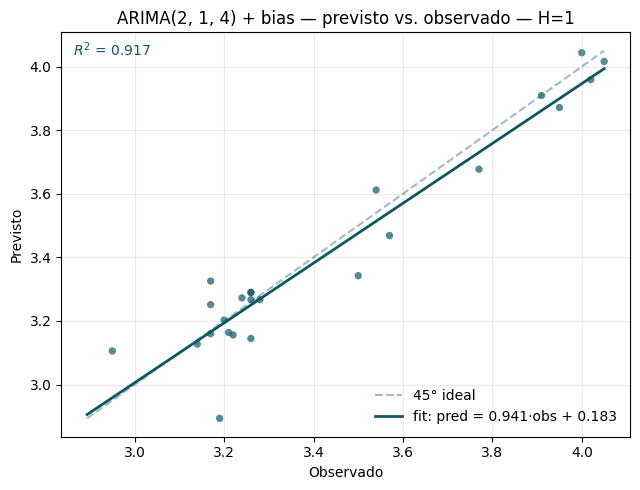

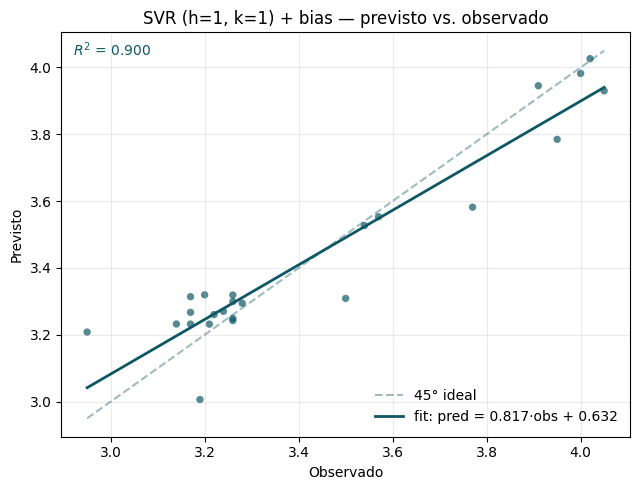

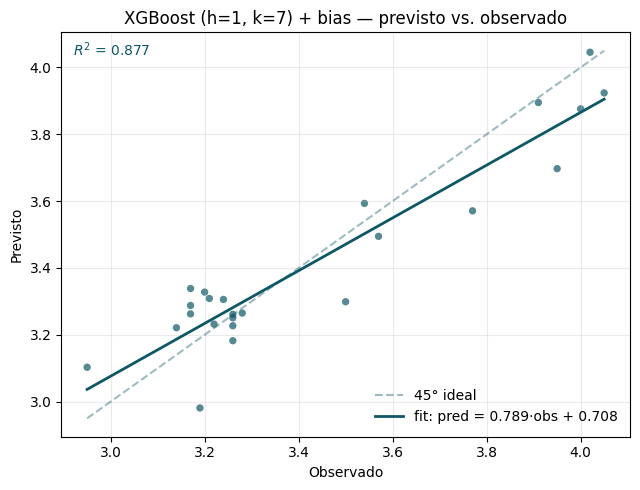

In [18]:
# =============================================================
# Gráficos observado vs. previsto — modelos com correção de bias
# =============================================================

COLOR = "#0e5764"

# Recria variáveis de apoio a partir dos objetos gerados pelos modelos.
# Isso evita erro de NameError caso y_true_h1_svr, y_true_h1_xgb,
# melhor_k_svr ou melhor_k_xgb não tenham sido criados em células anteriores.
melhor_k_svr = int(selecao_svr.sort_values("rmse_treino").iloc[0]["qtd_valores_historicos"])
melhor_k_xgb = int(selecao_xgb.sort_values("rmse_treino").iloc[0]["qtd_valores_historicos"])

y_true_h1_svr = df_reg.loc[yhat_svr_h1.index, TARGET_COL]
y_true_h1_xgb = df_reg.loc[yhat_xgb_h1.index, TARGET_COL]


def plot_regressao(y_true, y_pred, titulo):
    """
    Plota valores observados contra valores previstos.

    A linha diagonal representa o cenário ideal: observado = previsto.
    Pontos acima da diagonal indicam superestimação; pontos abaixo indicam subestimação.
    """
    df_plot = pd.concat(
        [pd.Series(y_true).rename("obs"), pd.Series(y_pred).rename("pred")],
        axis=1
    ).dropna()

    if df_plot.empty:
        raise ValueError("Não há observações suficientes para gerar o gráfico.")

    x = df_plot["obs"].values.reshape(-1, 1)
    y = df_plot["pred"].values

    lr = LinearRegression().fit(x, y)
    r2 = lr.score(x, y)
    slope = float(lr.coef_[0])
    intercept = float(lr.intercept_)

    xy_min = float(min(df_plot["obs"].min(), df_plot["pred"].min()))
    xy_max = float(max(df_plot["obs"].max(), df_plot["pred"].max()))
    xx = np.linspace(xy_min, xy_max, 100)

    plt.figure(figsize=(6.5, 5))

    plt.scatter(
        df_plot["obs"],
        df_plot["pred"],
        s=28,
        alpha=0.7,
        edgecolors="none",
        color=COLOR
    )

    plt.plot(
        [xy_min, xy_max],
        [xy_min, xy_max],
        "--",
        lw=1.5,
        alpha=0.4,
        color=COLOR,
        label="45° ideal"
    )

    plt.plot(
        xx,
        slope * xx + intercept,
        lw=2.0,
        color=COLOR,
        label=f"fit: pred = {slope:.3f}·obs + {intercept:.3f}"
    )

    plt.title(titulo)
    plt.xlabel("Observado")
    plt.ylabel("Previsto")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=False)

    plt.text(
        0.02,
        0.98,
        f"$R^2$ = {r2:.3f}",
        transform=plt.gca().transAxes,
        ha="left",
        va="top",
        fontsize=10,
        color=COLOR
    )

    plt.tight_layout()
    plt.show()


plot_regressao(
    y_true_h1,
    yhat_h1_bc,
    f"ARIMA{ordem_h1} + bias — previsto vs. observado — H=1"
)

plot_regressao(
    y_true_h1_svr,
    yhat_svr_h1_bc,
    f"SVR (h=1, k={melhor_k_svr}) + bias — previsto vs. observado"
)

plot_regressao(
    y_true_h1_xgb,
    yhat_xgb_h1_bc,
    f"XGBoost (h=1, k={melhor_k_xgb}) + bias — previsto vs. observado"
)

### Análise dos gráficos previsto vs. observado

Os gráficos previsto versus observado indicam que os três modelos conseguem acompanhar a tendência geral da inadimplência no período de teste, uma vez que os pontos se concentram próximos à linha de 45°, que representa o cenário ideal em que previsão e valor observado seriam iguais.

Entre os modelos avaliados, o ARIMA(2,1,4) com correção de bias apresentou o melhor desempenho geral. Esse modelo obteve o menor MAE (0,0705), menor RMSE (0,0973) e maior R² (0,9127), indicando maior proximidade entre os valores previstos e observados. Além disso, sua reta ajustada apresenta inclinação de 0,9408, mais próxima de 1 em comparação aos demais modelos, sugerindo que suas previsões acompanham melhor a variação da série observada.

O SVR também apresentou desempenho satisfatório, com RMSE de 0,1083 e R² de 0,8919. No entanto, sua inclinação de 0,8170 indica maior suavização das previsões, isto é, o modelo tende a reagir menos intensamente às variações da inadimplência observada. Como o melhor resultado do SVR ocorreu com `k=1`, o modelo utilizou apenas o valor contemporâneo da inadimplência (`inad_total`), sugerindo que, para esse modelo, a informação mais recente foi suficiente para produzir a melhor previsão no conjunto de teste.

O XGBoost apresentou o pior desempenho relativo entre os três modelos, com maior MAE (0,0973), maior RMSE (0,1203) e menor R² (0,8667). Apesar de utilizar a maior janela histórica (`k=7`), isto é, `inad_total` até `inad_total_L6`, suas previsões ficaram mais distantes da linha ideal, especialmente nos valores mais altos de inadimplência. A inclinação de 0,7894 indica que o modelo tende a comprimir as previsões, subestimando parte da variação observada.

De forma geral, os resultados indicam que o ARIMA foi o modelo mais adequado para a previsão um mês à frente da inadimplência no período analisado. Embora SVR e XGBoost também tenham apresentado boa capacidade explicativa, o ARIMA combinou menor erro, maior R² e melhor alinhamento visual entre valores previstos e observados.

In [19]:
# ─────────────────────────────────────────────────────────────
# EXPORTAÇÃO — resultados_baseline_h1.csv
# Cole esta célula ao final do Notebook 02, após a célula de
# "RANKING FINAL — MODELOS COM CORREÇÃO DE BIAS".
# ─────────────────────────────────────────────────────────────
# O DataFrame `comparativo_modelos` contém todos os modelos
# (com e sem bias). Exportamos diretamente para CSV.

CAMINHO_EXPORT_NB02 = "resultados_sem_sentimento.csv"

comparativo_modelos.to_csv(CAMINHO_EXPORT_NB02, index=False)

print(f"✅ Exportado: {CAMINHO_EXPORT_NB02}")
print(f"   Linhas: {len(comparativo_modelos)}  |  Colunas: {list(comparativo_modelos.columns)}")
display(comparativo_modelos.round(6))


✅ Exportado: resultados_sem_sentimento.csv
   Linhas: 6  |  Colunas: ['Modelo', 'MAE', 'RMSE', 'R2', 'Bias (obs - prev)', 'Slope pred~obs', 'Intercept', 'Ranking RMSE']


,Modelo,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept,Ranking RMSE
0,"ARIMA(2, 1, 4) (h=1) + bias",0.070517,0.097328,0.912723,0.019726,0.940752,0.183420,1
1,"ARIMA(2, 1, 4) (h=1)",0.072136,0.099060,0.909589,0.027005,0.940752,0.176141,2
2,"SVR (h=1, k=1) + bias",0.081045,0.108325,0.891885,-0.003964,0.816916,0.631715,3
3,"SVR (h=1, k=1)",0.083947,0.115626,0.876821,0.040629,0.816916,0.587122,4
4,"XGBoost (h=1, k=7) + bias",0.097261,0.120267,0.866734,0.014192,0.789437,0.707775,5
5,"XGBoost (h=1, k=7)",0.109156,0.139883,0.819717,0.072832,0.789437,0.649135,6
